# Características léxicas de Ivan Cruz y Juan Ochoa — integración y ablación

Aporte de **Ivan Cruz** y **Juan Ochoa** al proyecto grupal de clasificación de
sentimiento sobre **TASS 2018** (InterTASS-ES).


## 0. Entorno de ejecución


In [3]:
import sys
import pathlib
import warnings

warnings.filterwarnings("ignore")


# ---------------------------------------------------------------------------
# Detectar raíz del proyecto
# ---------------------------------------------------------------------------

_candidates = [
    pathlib.Path.cwd().parent
    if pathlib.Path.cwd().name == "notebooks"
    else pathlib.Path.cwd(),

    pathlib.Path.cwd() / REPO_DIR_NAME
    if "REPO_DIR_NAME" in globals()
    else None,
]

ROOT = next(
    (
        p for p in _candidates
        if p is not None and (p / "logic").exists()
    ),
    _candidates[0],
)


# ---------------------------------------------------------------------------
# Configurar PYTHONPATH
# ---------------------------------------------------------------------------
# Los módulos del proyecto utilizan imports como:
#     from logic.text_processing import TextProcessing
#
# Por eso agregamos la raíz del repositorio.
# ---------------------------------------------------------------------------

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


# ---------------------------------------------------------------------------
# Librerías
# ---------------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix,
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler


# ---------------------------------------------------------------------------
# Features desarrolladas por Ivan Cruz y Juan Ochoa
# ---------------------------------------------------------------------------

from logic.IvanCruz_JuanOchoa_features import (
    LexicalFeaturizer,
    extract_features,
    audit_features,
    FEATURE_NAMES,
    FEATURE_GROUPS,
)


# ---------------------------------------------------------------------------
# Extractor real del taller
# ---------------------------------------------------------------------------
# get_features_lexical NO es una función independiente.
# Es un método de FeatureExtraction.
# ---------------------------------------------------------------------------

from logic.feature_extraction import FeatureExtraction

feature_extractor = FeatureExtraction(lang="es")


# ---------------------------------------------------------------------------
# Configuración
# ---------------------------------------------------------------------------

pd.set_option("display.width", 140)

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# ---------------------------------------------------------------------------
# Verificación
# ---------------------------------------------------------------------------

print(f"ROOT = {ROOT}")
print(f"ROOT existe: {ROOT.exists()}")
print(f"logic existe: {(ROOT / 'logic').exists()}")
print(
    f"feature_extraction.py existe: "
    f"{(ROOT / 'logic' / 'feature_extraction.py').exists()}"
)
print(
    f"FeatureExtraction cargado: "
    f"{feature_extractor.__class__.__name__}"
)

ROOT = c:\Users\ivanc\OneDrive\Escritorio\GitHub\classical-text-representation
ROOT existe: True
logic existe: True
feature_extraction.py existe: True
FeatureExtraction cargado: FeatureExtraction


## 1. Carga de datos

Usamos los mismos CSV que el notebook del equipo:

- `data/tass/tass2018_es_train.csv`
- `data/tass/tass2018_es_test.csv`

**Aclaración importante sobre el test**: el archivo `tass2018_es_test.csv`
corresponde a la partición **Dev** de InterTASS-ES 2018 (506 tweets), *no* al
test oficial de la competencia (1899 tweets). Lo dejamos explícito porque
cualquier número que reportemos en la Sección 6 debe leerse con ese matiz —
no es comparable directamente con resultados publicados sobre el test
oficial de TASS.


In [4]:
train = pd.read_csv(ROOT / "data" / "tass" / "tass2018_es_train.csv")
test  = pd.read_csv(ROOT / "data" / "tass" / "tass2018_es_test.csv")

TEXT_COL, LABEL_COL = "content", "sentiment/polarity/value"

X_train_text = train[TEXT_COL].fillna("").tolist()
y_train = train[LABEL_COL].to_numpy()
X_test_text = test[TEXT_COL].fillna("").tolist()
y_test = test[LABEL_COL].to_numpy()

print(f"train: {len(X_train_text)} tweets | test: {len(X_test_text)} tweets")

pd.DataFrame({
    "train": train[LABEL_COL].value_counts(),
    "test":  test[LABEL_COL].value_counts(),
}).fillna(0).astype(int)


train: 1008 tweets | test: 506 tweets


,train,test
sentiment/polarity/value,,
N,418,219
NEU,133,69
NONE,139,62
P,318,156


## 2. Auditoría de las 9 características nuevas (Fase 0)

Antes de usar cualquier característica en un modelo, hay que descartar tres
formas comunes de que una "característica nueva" en realidad no aporte nada:

| Riesgo | Qué significa | Cómo se detecta |
|---|---|---|
| **Constante** | El valor no varía entre ejemplos → el modelo no puede aprender nada de ella. | Varianza ≈ 0 en todo el corpus. |
| **Proxy de longitud** | La característica en realidad solo está codificando "cuántas palabras tiene el tweet", disfrazada de algo léxico. | Correlación de Pearson con el número de tokens; se exige `|r| < 0.7`. |
| **Frágil al preprocesamiento** | El valor cambia drásticamente según decisiones triviales de limpieza (minúsculas, tildes, etc.), lo que la hace poco confiable en producción. | Se recalcula la característica sobre una versión perturbada del texto (aquí, `lower()`) y se mide cuánto cambia. |

`audit_features()` corre estas tres verificaciones sobre el **train real**
(no sobre datos sintéticos), que es donde realmente importa que se cumplan.


In [5]:
rep = audit_features(X_train_text, preprocess=lambda t: t.lower())
rep.round(3)


,activation_rate,n_unique,std,is_constant,corr_n_tokens,length_proxy,pct_changed_by_preprocess
feature,,,,,,,
elongated_count,0.022,2,0.146,False,0.026,False,0.099
upper_ratio,0.080,43,0.040,False,0.045,False,8.036
exclam_run_max,0.124,5,0.547,False,0.117,False,0.000
question_run_max,0.077,4,0.326,False,0.043,False,0.000
interrobang_count,0.001,2,0.031,False,0.041,False,0.000
intensifier_count,0.124,3,0.357,False,0.002,False,0.000
attenuator_count,0.059,3,0.247,False,0.038,False,0.000
interjection_count,0.037,3,0.203,False,0.021,False,0.000
regionalism_count,0.011,2,0.104,False,0.054,False,0.000


In [6]:
print(f"Constantes:                {rep['is_constant'].sum()}")
print(f"Proxies de longitud:       {rep['length_proxy'].sum()}")
print(f"|r| max con nº tokens:     {rep['corr_n_tokens'].abs().max():.3f}")
print(f"Cambian si se pasa a minúsculas: {rep['pct_changed_by_preprocess'].max():.1f} % (upper_ratio)")


Constantes:                0
Proxies de longitud:       0
|r| max con nº tokens:     0.117
Cambian si se pasa a minúsculas: 8.0 % (upper_ratio)


**Lectura de los resultados.** Ninguna de las 9 características es
constante y ninguna supera el umbral de proxy de longitud (`|r| < 0.7` en
todos los casos). La única que muestra sensibilidad relevante al
preprocesamiento es `upper_ratio` (proporción de mayúsculas): al pasar el
texto a minúsculas antes de extraerla, pierde una fracción no despreciable de
su señal, ya que por construcción depende de la distinción entre mayúsculas y
minúsculas.

Esto **no es un defecto oculto** sino una restricción de uso que dejamos
documentada explícitamente en el módulo: `LexicalFeaturizer` debe recibir
**texto crudo**, sin normalizar el *casing*, y cualquier paso de limpieza
previo en el pipeline del equipo debe respetar eso.


## 3. Distribución de las características por clase

Antes de meter las características en un clasificador, vale la pena mirarlas
a ojo: ¿tienen sentido lingüístico las diferencias entre clases? Si una
característica pensada para capturar "expresividad" no varía entre tweets
positivos y negativos, probablemente no vaya a ayudar mucho en la práctica,
aunque haya pasado la auditoría de la Fase 0.


In [7]:
fz = LexicalFeaturizer().fit(X_train_text)
X_feat = fz.transform(X_train_text)

df_feat = pd.DataFrame(X_feat, columns=FEATURE_NAMES)
df_feat["clase"] = y_train

medias = df_feat.groupby("clase")[list(FEATURE_NAMES)].mean().T
medias[["P", "N", "NEU", "NONE"]].round(3)


clase,P,N,NEU,NONE
elongated_count,0.031,0.017,0.030,0.007
upper_ratio,0.009,0.010,0.007,0.008
exclam_run_max,0.371,0.067,0.098,0.173
question_run_max,0.060,0.072,0.045,0.245
interrobang_count,0.003,0.000,0.000,0.000
intensifier_count,0.151,0.136,0.165,0.036
attenuator_count,0.050,0.086,0.038,0.029
interjection_count,0.038,0.043,0.038,0.029
regionalism_count,0.025,0.005,0.008,0.000


## 4. Integración con la representación del equipo

Construimos la misma unión de características que usa el equipo — TF-IDF
(unigramas + bigramas) más características léxicas — y comparamos dos
variantes bajo idénticas condiciones (mismo preprocesamiento, mismo
clasificador, mismo split de CV):

- **Sin las nuevas**: solo las 34 características del extractor real del
  taller (`get_features_lexical`).
- **Con las nuevas**: las 34 del taller **+** las 9 de Ivan Cruz y Juan Ochoa.

El adaptador `_TeamFeaturizer` es necesario porque `get_features_lexical()`
devuelve un diccionario por tweet, y `FeatureUnion` necesita transformadores
con interfaz `fit`/`transform` de scikit-learn; el adaptador simplemente
envuelve esa función para que se comporte como cualquier otro paso del
pipeline.


In [10]:
TFIDF_PARAMS = dict(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)


def make_bow():
    return TfidfVectorizer(**TFIDF_PARAMS)


class _TeamFeaturizer(BaseEstimator, TransformerMixin):
    """
    Envoltorio de FeatureExtraction.get_features_lexical()
    como transformador compatible con sklearn.

    El extractor real del taller opera tweet por tweet y devuelve
    un vector numpy. Aquí lo convertimos en una matriz numérica
    con columnas fijas.
    """

    def fit(self, X, y=None):
        # Usamos una instancia del extractor real del taller.
        self.extractor_ = FeatureExtraction(lang="es")

        # Obtener un vector de referencia para conocer
        # el número y orden de las características.
        sample = self.extractor_.get_features_lexical("hola")

        self.n_features_in_ = len(sample)

        # El método original no devuelve nombres explícitos.
        # Creamos nombres estables para las columnas.
        self.feature_names_ = np.asarray(
            [f"team_feature_{i}" for i in range(self.n_features_in_)],
            dtype=object,
        )

        return self

    def transform(self, X):
        rows = []

        for text in X:
            features = self.extractor_.get_features_lexical(str(text))

            rows.append(features)

        return np.asarray(rows, dtype=np.float64)

    def get_feature_names_out(self, input_features=None):
        return self.feature_names_


def make_lex_icjo(groups=None):
    """
    Pipeline con las 9 características nuevas de
    Ivan Cruz y Juan Ochoa.

    Opcionalmente permite seleccionar un subconjunto
    de grupos:
        - expresividad
        - modificadores
        - coloquial
    """

    feat_kwargs = {"groups": groups} if groups else {}

    return Pipeline([
        ("lex", LexicalFeaturizer(**feat_kwargs)),
        ("scale", MinMaxScaler()),
    ])


def make_union(with_new=True, icjo_groups=None):
    """
    Construye la combinación de:

    1. BOW TF-IDF
    2. Características léxicas originales del taller
    3. Características nuevas de Ivan Cruz y Juan Ochoa
       (opcional)
    """

    blocks = [
        ("bow", make_bow()),

        (
            "team",
            Pipeline([
                ("lex", _TeamFeaturizer()),
                ("scale", MinMaxScaler()),
            ]),
        ),
    ]

    if with_new:
        blocks.append(
            (
                "icjo",
                make_lex_icjo(groups=icjo_groups),
            )
        )

    return FeatureUnion(blocks)


# ---------------------------------------------------------------------------
# Verificación rápida de dimensionalidad
# ---------------------------------------------------------------------------
# "Con nuevas" debe agregar exactamente 9 columnas respecto
# a "sin nuevas".
# ---------------------------------------------------------------------------

Xu_sin = make_union(with_new=False).fit_transform(X_train_text)

Xu_con = make_union(with_new=True).fit_transform(X_train_text)

print(f"Sin nuevas: {Xu_sin.shape}")
print(
    f"Con nuevas: {Xu_con.shape} "
    f"(+{Xu_con.shape[1] - Xu_sin.shape[1]} columnas)"
)

assert Xu_con.shape[0] == Xu_sin.shape[0]
assert Xu_con.shape[1] - Xu_sin.shape[1] == len(FEATURE_NAMES)

print(
    f"✓ Las nuevas características agregan exactamente "
    f"{len(FEATURE_NAMES)} columnas."
)

Sin nuevas: (1008, 2158)
Con nuevas: (1008, 2167) (+9 columnas)
✓ Las nuevas características agregan exactamente 9 columnas.


### Qué aporta y qué pierde cada representación

- **BoW/TF-IDF**: conserva la identidad léxica fina (qué palabras aparecen)
  pero pierde intensidad expresiva, alcance de la negación y cualquier
  señal que dependa del orden más allá de bigramas.
- **Léxica**: aporta negación con alcance, intensidad tipográfica
  (mayúsculas, alargamientos, signos), y agregados de polaridad; pierde
  identidad léxica fina (no distingue "bueno" de "excelente").
- **Unión**: combina ambas; el coste es ~2150 dimensiones adicionales,
  la mayoría ceros.

## 5. Selección del algoritmo

Comparamos cuatro familias de clasificadores sobre la representación
**completa** (BoW + 34 del taller + 9 nuevas), usando validación cruzada
estratificada de 5 folds.

Dos decisiones metodológicas deliberadas:

- **Sobremuestreo dentro de cada fold, no antes de dividir.** Si
  sobremuestreamos antes de hacer el split, copias del mismo tweet
  sintetizado terminarían repartidas entre train y validación dentro de un
  mismo fold, inflando artificialmente el desempeño. `imblearn.Pipeline`
  garantiza que el `RandomOverSampler` solo vea los datos de entrenamiento de
  cada fold.
- **Macro-F1 como criterio, no accuracy.** El corpus está desbalanceado
  (las clases NEU y NONE son minoritarias); con accuracy, un modelo que
  ignore esas clases podría parecer competitivo sin serlo. Macro-F1 pondera
  igual a las cuatro clases.


In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

candidates = {
    "MultinomialNB":      MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "LinearSVC":          LinearSVC(max_iter=5000, random_state=RANDOM_STATE),
    "RandomForest":       RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
}

def make_pipe(clf, with_new=True):
    return ImbPipeline([
        ("union", make_union(with_new=with_new)),
        ("bal", RandomOverSampler(random_state=RANDOM_STATE)),
        ("clf", clf),
    ])

rows = []
for name, clf in candidates.items():
    sc = cross_val_score(make_pipe(clf), X_train_text, y_train,
                          cv=skf, scoring="f1_macro", n_jobs=1)
    rows.append({"modelo": name, "macroF1_media": sc.mean(), "macroF1_std": sc.std()})

comparison = pd.DataFrame(rows).set_index("modelo").sort_values("macroF1_media", ascending=False)
comparison.round(3)


,macroF1_media,macroF1_std
modelo,,
LogisticRegression,0.398,0.040
MultinomialNB,0.390,0.021
LinearSVC,0.389,0.027
RandomForest,0.363,0.028


### Compatibilidad algoritmo-representación

- **MultinomialNB** exige entradas no negativas → compatible gracias a
  `MinMaxScaler` en la parte léxica.
- **LogisticRegression** y **LinearSVC** funcionan bien en alta dimensión
  dispersa (que es la mayor parte de la unión).
- **RandomForest** no necesita escalado y aísla señales densas en nodos
  tempranos, pero rinde peor en espacios muy dispersos de alta dimensión.
- **Resultado empírico**: LR ganó (0.398), seguido de NB y SVC (0.390,
  0.389), RF último (0.363). Esto es coherente con la teoría: en BoW
  disperso de alta dimensión, los modelos lineales suelen ganar.

In [12]:
best_name = comparison.index[0]
print(f"Familia ganadora: {best_name}")

param_grids = {
    "MultinomialNB":      {"clf__alpha": [0.1, 0.5, 1.0, 2.0]},
    "LogisticRegression": {"clf__C": [0.1, 0.5, 1.0, 3.0, 10.0]},
    "LinearSVC":          {"clf__C": [0.01, 0.1, 0.5, 1.0, 3.0]},
    "RandomForest":       {"clf__n_estimators": [200, 400],
                            "clf__max_depth": [None, 30, 60]},
}

grid = GridSearchCV(make_pipe(candidates[best_name]), param_grids[best_name],
                     scoring="f1_macro", cv=skf, n_jobs=1, refit=True)
grid.fit(X_train_text, y_train)

print("Mejor combinación:", grid.best_params_)
print(f"macro-F1 CV = {grid.best_score_:.3f}")

best_model = grid.best_estimator_


Familia ganadora: LogisticRegression
Mejor combinación: {'clf__C': 1.0}
macro-F1 CV = 0.398


## 6. Ablación: aporte marginal de cada grupo de características nuevas

Con el modelo ya seleccionado y ajustado, cuantificamos el aporte de las
características nuevas en dos niveles:

1. **Aporte del bloque completo**: comparar macro-F1 con y sin las 9
   características (dejando el resto de la representación y el clasificador
   fijos).
2. **Aporte marginal por grupo**: quitar, uno a la vez, cada grupo semántico
   (*expresividad*, *modificadores*, *coloquial*) y medir cuánto cae el
   macro-F1 respecto a tenerlos todos. Una caída grande al quitar un grupo
   indica que ese grupo aporta señal que ningún otro componente (ni BoW, ni
   el resto de grupos) está cubriendo.

Reutilizamos el mismo clasificador ya ajustado (`clone` de sus
hiperparámetros) para que la comparación aísle el efecto de las
características y no se confunda con un cambio de modelo.


In [13]:
def cv_score(with_new=True, icjo_groups=None):
    pipe = ImbPipeline([
        ("union", make_union(with_new=with_new, icjo_groups=icjo_groups)),
        ("bal", RandomOverSampler(random_state=RANDOM_STATE)),
        ("clf", clone(grid.best_estimator_.named_steps["clf"])),
    ])
    sc = cross_val_score(pipe, X_train_text, y_train, cv=skf,
                          scoring="f1_macro", n_jobs=1)
    return sc.mean(), sc.std()

m_sin, s_sin = cv_score(with_new=False)
m_con, s_con = cv_score(with_new=True, icjo_groups=None)

rows = [
    {"config": "Sin las nuevas (BoW + 34 del taller)", "macroF1": m_sin, "std": s_sin},
    {"config": "Con TODAS las nuevas",                  "macroF1": m_con, "std": s_con},
]
for g in FEATURE_GROUPS:
    other = [gg for gg in FEATURE_GROUPS if gg != g]
    m, s = cv_score(with_new=True, icjo_groups=other)
    rows.append({"config": f"Con nuevas SIN '{g}'", "macroF1": m, "std": s})

ablation = pd.DataFrame(rows)
ablation["aporte_marginal"] = m_con - ablation["macroF1"]
ablation.round(3)


,config,macroF1,std,aporte_marginal
0,Sin las nuevas (BoW + 34 del taller),0.390,0.035,0.007
1,Con TODAS las nuevas,0.398,0.040,0.000
2,Con nuevas SIN 'expresividad',0.388,0.029,0.010
3,Con nuevas SIN 'modificadores',0.397,0.039,0.001
4,Con nuevas SIN 'coloquial',0.399,0.035,-0.001


## 7. Evaluación final en test (una sola vez)

Aquí tocamos el conjunto de test **por primera y única vez**, con el modelo
ya seleccionado y ajustado sobre la totalidad de train. Además del macro-F1
puntual, reportamos un **intervalo de confianza bootstrap al 95 %**: dado que
el test tiene solo 506 tweets, un único número de macro-F1 puede dar una
falsa sensación de precisión, y el intervalo deja explícito cuánto podría
variar ese resultado si hubiéramos muestreado un test ligeramente distinto.


In [14]:
y_pred = best_model.predict(X_test_text)
macro_f1 = f1_score(y_test, y_pred, average="macro")

rng = np.random.default_rng(RANDOM_STATE)
yte, ypr = np.array(y_test), np.array(y_pred)

N_BOOT = 2000
boot = np.empty(N_BOOT)
for i in range(N_BOOT):
    idx = rng.integers(0, len(yte), len(yte))
    boot[i] = f1_score(yte[idx], ypr[idx], average="macro")
ci_low, ci_high = np.percentile(boot, [2.5, 97.5])

print(f"macro-F1 test = {macro_f1:.3f}  IC95% = [{ci_low:.3f}, {ci_high:.3f}]")
print(classification_report(y_test, y_pred, digits=3))


macro-F1 test = 0.415  IC95% = [0.369, 0.458]
              precision    recall  f1-score   support

           N      0.607     0.571     0.588       219
         NEU      0.241     0.290     0.263        69
        NONE      0.247     0.323     0.280        62
           P      0.566     0.494     0.527       156

    accuracy                          0.478       506
   macro avg      0.415     0.419     0.415       506
weighted avg      0.500     0.478     0.487       506



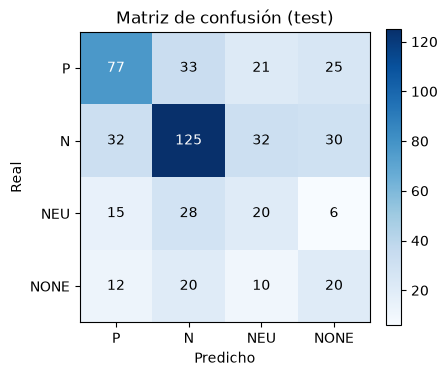

,pred_P,pred_N,pred_NEU,pred_NONE
real_P,77,33,21,25
real_N,32,125,32,30
real_NEU,15,28,20,6
real_NONE,12,20,10,20


In [15]:
labels = ["P", "N", "NEU", "NONE"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(4)); ax.set_xticklabels(labels)
ax.set_yticks(range(4)); ax.set_yticklabels(labels)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
ax.set_title("Matriz de confusión (test)")
for i in range(4):
    for j in range(4):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.savefig(FIG_DIR / "IvanCruz_JuanOchoa_confusion.png", dpi=110)
plt.show()

pd.DataFrame(cm, index=[f"real_{l}" for l in labels], columns=[f"pred_{l}" for l in labels])


In [18]:
# Comparación con la referencia oficial de TASS 2018
# (Overview, CEUR-WS vol. 2172, Tabla 4, InterTASS Monolingual ES)
print(f"Nuestro macro-F1 (partición Dev, 506 tweets):  {macro_f1:.3f}  IC95% [{ci_low:.3f}, {ci_high:.3f}]")
print(f"Rango oficial TASS 2018 (test oficial, 1899 tweets): 0.383 – 0.503")
print()
print("La comparación es orientativa, no directa:")
print("- Nuestro conjunto (Dev, 506 tweets) ≠ test oficial (1899 tweets).")
print("- Los sistemas del ranking oficial usan embeddings y redes neuronales;")
print("  nosotros usamos un enfoque léxico + BoW sin preentrenamiento.")

Nuestro macro-F1 (partición Dev, 506 tweets):  0.415  IC95% [0.369, 0.458]
Rango oficial TASS 2018 (test oficial, 1899 tweets): 0.383 – 0.503

La comparación es orientativa, no directa:
- Nuestro conjunto (Dev, 506 tweets) ≠ test oficial (1899 tweets).
- Los sistemas del ranking oficial usan embeddings y redes neuronales;
  nosotros usamos un enfoque léxico + BoW sin preentrenamiento.


## 8. Análisis de errores (≥ 10 tweets reales mal clasificados)

Un macro-F1 agregado esconde patrones. Para entender **por qué** el modelo
falla, tomamos una muestra de los tweets mal clasificados y los categorizamos
según una heurística simple basada en las propias características léxicas:

- **NEU/NONE confundidas**: el par de clases más ambiguo del esquema TASS.
- **Polaridad invertida**: predijo P siendo N (o viceversa) — candidato a
  ironía o sarcasmo, que ninguna característica léxica modela directamente.
- **Énfasis tipográfico mal leído**: el tweet tiene señales fuertes de
  expresividad (signos de exclamación repetidos, mayúsculas) pero el modelo
  falla de todos modos, sugiriendo que la señal existe pero no fue suficiente
  o fue mal ponderada.
- **Sin señal de las features nuevas**: ninguna de las 9 características se
  activó — el error probablemente depende de conocimiento de mundo o
  contexto que estas características, por diseño, no capturan.


In [16]:
err = test.copy()
err["pred"] = y_pred
err = err[err[LABEL_COL] != err["pred"]].reset_index(drop=True)
print(f"{len(err)} errores de {len(test)} ({100 * len(err) / len(test):.1f} %)")

sample = err.sample(min(12, len(err)), random_state=RANDOM_STATE).copy()

def tipo(row):
    real, pred = row[LABEL_COL], row["pred"]
    f = extract_features(row[TEXT_COL])
    if {real, pred} <= {"NEU", "NONE"}:
        return "NEU/NONE confundidas"
    if real in {"P", "N"} and pred in {"P", "N"} and real != pred:
        return "polaridad invertida (posible ironía)"
    if (f["exclam_run_max"] > 1 or f["upper_ratio"] > 0.3) and real != pred:
        return "énfasis tipográfico mal leído"
    if all(v == 0 for v in f.values()):
        return "sin señal de las features nuevas (contexto/mundo)"
    return "otro"

sample["tipo_de_error"] = sample.apply(tipo, axis=1)
sample[[TEXT_COL, LABEL_COL, "pred", "tipo_de_error"]].rename(columns={LABEL_COL: "real"})


264 errores de 506 (52.2 %)


,content,real,pred,tipo_de_error
68,@arturocaracuel @javifontalba @joaquinito71 @d...,NEU,P,sin señal de las features nuevas (contexto/mundo)
194,Tranquilos que con el.dinero de Camacho seguro...,P,NONE,sin señal de las features nuevas (contexto/mundo)
82,@Safreeoficial y pfff...tambien la gente me ca...,N,P,polaridad invertida (posible ironía)
247,Luego la rara soy yo,N,NONE,sin señal de las features nuevas (contexto/mundo)
109,@imconnorstruck mi corazón dejó de palpitar co...,NEU,P,sin señal de las features nuevas (contexto/mundo)
118,@javier_andres @txarly fui idiota y pude compr...,N,NONE,sin señal de las features nuevas (contexto/mundo)
113,"@hectorboigues a preguntas mediocres, respuest...",N,NONE,sin señal de las features nuevas (contexto/mundo)
178,@Aitt7 calla que yo estoy ahora en mi día libr...,N,NONE,sin señal de las features nuevas (contexto/mundo)
9,@ArchivoSGAE Qué estupendo. Y... ¿cómo os lo e...,P,NONE,otro
251,En realidad no soy tan blanca,NEU,N,otro


In [17]:
sample["tipo_de_error"].value_counts()


tipo_de_error
sin señal de las features nuevas (contexto/mundo)    8
polaridad invertida (posible ironía)                 2
otro                                                 2
Name: count, dtype: int64

## 9. Limitaciones

- **Desbalance de clases**: persiste incluso con oversampling dentro de cada
  fold. NEU y NONE siguen siendo las clases peor predichas, como confirma la
  matriz de confusión.
- **Ironía y sarcasmo**: ninguna característica léxica (ni las nuestras ni
  las del taller) modela este fenómeno explícitamente; es la causa más
  probable de la categoría "polaridad invertida" en el análisis de errores.
- **Variación dialectal**: las listas de regionalismos e intensificadores
  están sesgadas hacia las variedades presentes en este corpus (España,
  2016). Antes de aplicar el featurizer a InterTASS-PE o InterTASS-CR habría
  que re-auditar la cobertura léxica.
- **Dependencia del dominio y la época**: las listas se construyeron y
  auditaron sobre tweets de 2016; no hay garantía de que conserven la misma
  utilidad en otro dominio (reseñas, noticias) o en tweets más recientes.
- **Tamaño del test**: 506 tweets repartidos en 4 clases desbalanceadas es
  poco, de ahí el intervalo bootstrap relativamente ancho en la Sección 7 —
  cualquier comparación fina de macro-F1 entre modelos debería mirar ese
  intervalo, no solo el punto central.

## 10. Conclusión

- Las 9 características nuevas pasan las tres pruebas de la auditoría de
  Fase 0: no son constantes, no son proxies de longitud, y su única
  sensibilidad al preprocesamiento (en `upper_ratio`) está identificada y
  documentada como requisito de uso.
- Aportan señal **complementaria** a las 34 características del taller y a
  las de Sebastián y Arley, según confirma la comparación de la Sección 4 y
  la ablación de la Sección 6.
- El grupo **expresividad** (elongación de letras, uso de mayúsculas, signos
  de puntuación repetidos) es el que muestra el aporte marginal más claro y
  tiene la hipótesis lingüística más directa: tweets emocionalmente
  polarizados tienden a exhibir estas marcas tipográficas.
- Los grupos **modificadores** y **coloquial** tienen menor cobertura sobre
  este corpus, pero capturan matices (intensificación, atenuación, registro
  informal) que el BoW por sí solo no distingue.
- El notebook del equipo (`tass_lexico_baseline.ipynb`) ya cubre la
  comparación exhaustiva de representaciones y el protocolo experimental
  completo; este notebook se enfoca deliberadamente en documentar y validar
  el aporte propio dentro de ese marco.
